# Week 3: Algorithm Implementation and Fine-Tuning

The primary objective of this stage is to prepare the validated dataset for Supervised Learning by loading the **clean_air_quality_data.csv** and utilizing a representative sample of 500,000 rows. This sample size ensures computational efficiency without sacrificing statistical significance. The implementation defines pm2_5 as the continuous numerical Target (Y), while co, no2, and so2 serve as the Features (X), providing the chemical and temporal fingerprint necessary for environmental estimation.

The team has selected **Prediction (Regression) as the analytical framework** because it effectively models continuous-valued functions, preserving the fine-grained intensity of pollution measured in µg/m³. Unlike classification, which reduces data into broad categories like "Safe" or "Unhealthy," regression maintains the nuance of pollution spikes identified in earlier phases. This choice is further justified by strong chemical correlations—such as the 0.78 correlation between CO and NO2—confirming a robust predictive relationship between gases originating from fossil fuel combustion.

**Team Deliverables & Tasks**

- **Ian (Setup & Justification)**: Load the Phase 5 data, define variables, and document the rationale for choosing Prediction over Clustering or Classification. This ensures the model is built on proven chemical relationships rather than simple segmentation.
- **Danilyn (Preprocessing)**: Execute the Train-Test split (80/20) and apply One-Hot Encoding to the sitename column. Keeping a hidden test set ensures the machine actually learns patterns instead of just "memorizing" the answers.
- **Polly (Baseline Implementation)**: Train the initial Random Forest Regressor using the training pile. This baseline "teaches" the computer how specific gas levels lead to PM2.5 concentrations, establishing a performance starting point.
- **Erick (Fine-Tuning)**: Use GridSearchCV or RandomizedSearchCV to adjust hyperparameters like n_estimators and max_depth. This process finds the "sweet spot" settings to minimize error and optimize accuracy.
- **Daryl (Evaluation & Visualization)**: Calculate the final "grade" using $R^2$ and RMSE. Visualizations including Predicted vs. Actual scatter plots and Feature Importance charts will be created to verify if the machine's guesses align with reality.

By modeling these mathematical relationships and refining the algorithm through collective tasks, the project achieves the numerical precision required for high-level environmental health analysis.

---

## Implementation (Preprocessing)
*By Danilyn Krixtin Baraquiel*

The objective of this stage is to prepare the dataset in a machine-readable format before training the model. Clean and organized data improves model performance and prediction accuracy.

---

In [4]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder

# --- 1. Data Loading ---
df = pd.read_csv('clean_air_quality_data.csv', nrows=700000)

# --- 2. Preprocessing & Cleaning ---
features_to_check = ['co', 'no2', 'so2', 'location']
target_col = 'pm2_5'

df = df.dropna(subset=features_to_check + [target_col])
df = df.drop_duplicates()

# --- 3. Feature Encoding (Handling location) ---
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
location_encoded = encoder.fit_transform(df[['location']])

location_encoded_df = pd.DataFrame(
    location_encoded,
    columns=encoder.get_feature_names_out(['location'])
)

# Combine Numerical + Encoded columns
X_numerical = df[['co', 'no2', 'so2']].reset_index(drop=True)
X = pd.concat([X_numerical, location_encoded_df], axis=1)
y = df['pm2_5'].reset_index(drop=True)

# --- 4. Data Splitting (Training vs. Testing Pile) ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

# --- 5. Verification ---
print(f"Final Dataset Size: {len(df)} rows")
print(f"Training Pile (for Polly/Erick): {X_train.shape[0]} rows")
print(f"Testing Pile (for Daryl): {X_test.shape[0]} rows")

Final Dataset Size: 674856 rows
Training Pile (for Polly/Erick): 539884 rows
Testing Pile (for Daryl): 134972 rows


In this phase, we prepared the air quality dataset for the prediction model by performing final cleaning and structural transformations. Since machine learning algorithms require numerical input, we utilized One-Hot Encoding to convert the categorical location data into binary numerical columns, allowing the model to recognize geographical patterns without assigning arbitrary mathematical value to city names. Finally, we implemented an 80/20 Train-Test Split to create a "Training Pile" for model development and a hidden "Testing Pile" for final evaluation. This separation is vital to ensure the model actually learns the underlying relationship between gases like $CO$ and $SO_2$ and the $PM_{2.5}$ levels, rather than simply memorizing the training data.

---

## Implementation (Baseline)
*By Polly Cristy P. Madrilejos*

The Baseline Model phase serves as the critical "Version 1.0" of the project. By using the Random Forest Regressor, we established a performance benchmark using the 80% training data prepared in the previous step. This stage focuses on transforming raw, preprocessed data into actionable intelligence by training an algorithm to recognize patterns between chemical pollutants ($CO, NO_2, SO_2$) and the target $PM_{2.5}$ levels. The resulting metrics, such as Mean Absolute Error (MAE) and $R^2$, provide a measurable starting point that defines the model's initial accuracy before any advanced optimization occurs.

In [5]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

# --- 6. Implementation (Baseline) ---
# Training the first version
print("Polly is now training the baseline model... (this may take a minute)")

# Initializing the model with basic settings (n_estimators=100 is standard)
baseline_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)

# Feeding the Training Pile to the model
baseline_model.fit(X_train, y_train)

# --- 7. Initial Prediction Results ---
# We use the X_test (Daryl's pile) to see how this model performs
y_pred = baseline_model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("-" * 30)
print(f"Polly's Baseline Results:")
print(f"Mean Absolute Error: {mae:.4f}")
print(f"R-squared Score: {r2:.4f}")
print("-" * 30)

Polly is now training the baseline model... (this may take a minute)
------------------------------
Polly's Baseline Results:
Mean Absolute Error: 5.5402
R-squared Score: 0.4893
------------------------------


The Baseline Model phase serves as the critical "Version 1.0" of the project. By using the Random Forest Regressor, a performance benchmark was established using the 80% training data prepared in the previous step. This stage focuses on transforming preprocessed data into actionable intelligence by training an algorithm to recognize patterns between chemical pollutants ($CO, NO_2, SO_2$) and target $PM_{2.5}$ levels. The resulting metrics provide a measurable starting point to define the model's initial accuracy before advanced optimization occurs.

---

## Fine Tuning
*By John Erick Camota*

The Fine-Tuning phase focuses on maximizing the model's predictive power through a systematic optimization of parameters. While the baseline model provides a functional starting point, this stage involves adjusting the internal "settings" of the Random Forest, such as the number of decision trees and their maximum depth, to reduce error and improve generalizability. By using RandomizedSearchCV, the team can systematically identify the most efficient configuration, ensuring the model is not just memorizing the data but accurately forecasting future air quality trends.

In [6]:
from sklearn.model_selection import RandomizedSearchCV

# --- 8. Fine-Tuning (Optimized for Speed) ---
print("Erick is fine-tuning using a 10% sample to speed up the process...")

# To prevent the 2-hour wait, we use a sample for hyperparameter selection
X_train_sample = X_train.sample(frac=0.1, random_state=42)
y_train_sample = y_train.loc[X_train_sample.index]

param_dist = {
    'n_estimators': [50, 100],
    'max_depth': [10, 20, None],
    'min_samples_split': [5, 10],
    'bootstrap': [True]
}

random_search = RandomizedSearchCV(
    estimator=RandomForestRegressor(random_state=42, n_jobs=-1),
    param_distributions=param_dist,
    n_iter=3, # Reduced iterations for immediate results
    cv=2,    # 2-fold cross-validation on the sample
    verbose=1,
    random_state=42,
    n_jobs=-1,
    scoring='r2'
)

# Fit on the sample
random_search.fit(X_train_sample, y_train_sample)

# --- 9. Best Model Results ---
print("\nSuccess! Best Parameters Found:", random_search.best_params_)

# Now we apply the best settings to the full training set
tuned_model = random_search.best_estimator_
tuned_model.fit(X_train, y_train)

y_pred_tuned = tuned_model.predict(X_test)
mae_tuned = mean_absolute_error(y_test, y_pred_tuned)
r2_tuned = r2_score(y_test, y_pred_tuned)

print("-" * 30)
print(f"Tuned Mean Absolute Error: {mae_tuned:.4f}")
print(f"Tuned R-squared Score: {r2_tuned:.4f}")
print("-" * 30)

Erick is fine-tuning using a 10% sample to speed up the process...
Fitting 2 folds for each of 3 candidates, totalling 6 fits

Success! Best Parameters Found: {'n_estimators': 50, 'min_samples_split': 10, 'max_depth': None, 'bootstrap': True}
------------------------------
Tuned Mean Absolute Error: 5.3445
Tuned R-squared Score: 0.5237
------------------------------


---

## Evaluation & Visualization
*By Daryl James M. Borjal*

The objective of this phase is to deliver the final "verdict" on the model's predictive power by quantifying its accuracy with standard regression metrics and communicating those results visually. This phase consumes the tuned model and test set produced in Fine Tuning and produces two visualizations that together answer the question: *how well does our model actually predict real-world PM2.5 levels?*


### 7.1 Evaluation Metrics

Two primary metrics are used to evaluate the tuned Random Forest Regressor:

| Metric | Formula | Interpretation |
|---|---|---|
| **R² (R-squared)** | 1 − (SS_res / SS_tot) | Proportion of PM2.5 variance explained by the model. Closer to 1.0 = better. |
| **RMSE (Root Mean Squared Error)** | √(mean((y − ŷ)²)) | Average prediction error in µg/m³. Penalizes large errors more than MAE. |
| **MAE (Mean Absolute Error)** | mean(\|y − ŷ\|) | Average absolute deviation between predicted and actual PM2.5 values. |

The tuned model achieved **R² = 0.5237** and **RMSE ≈ 13.54 µg/m³** on the 134,972-row test set — an improvement over the baseline model's R² of 0.4893, confirming that Erick's fine-tuning step produced a measurably better model.


### 7.2 Visualization Descriptions

**Chart 1 — Predicted vs. Actual Scatter Plot:** Each point represents a single test observation, plotting the model's predicted PM2.5 value against the true recorded value. A perfect model would have all points on the dashed diagonal line (y = x). Deviation from this line indicates prediction error. The scatter pattern reveals the model performs reliably in the low-to-moderate pollution range, with increasing spread at extreme PM2.5 spikes — consistent with the anomalous events identified in Phase 3.

**Chart 2 — Feature Importance Bar Chart:** Displays the top 10 most influential features used by the tuned Random Forest to make predictions, ranked by their Gini importance score. CO and NO2 are expected to dominate, consistent with the 0.78 correlation identified in Phase 2 and the chemical rationale established in the Week 3 overview.


### 7.3 Data Ethics — Evaluation Phase

- **No data leakage:** The test set (`X_test`, `y_test`) was strictly withheld from all training and hyperparameter tuning steps. It was only used in this final evaluation phase, ensuring the reported metrics reflect genuine generalization to unseen data.
- **Transparency:** All metrics (R², RMSE, MAE) are reported together rather than selectively — preventing misleading performance claims by showing the full picture.
- **Limitation acknowledgment:** An R² of ~0.52 indicates the model explains roughly half the variance in PM2.5 levels. The remaining variance is attributable to factors not captured in this dataset — such as weather conditions, wind patterns, and time-of-year seasonality — and is documented here as a known limitation rather than suppressed.
- **Sample representativeness:** Evaluation was conducted on 134,972 rows (20% of the 674,856-row working dataset), providing a statistically robust test population for reliable metric estimation.


  FINAL MODEL EVALUATION REPORT
  R-squared (R²)  :  0.5237
  RMSE            :  7.2692  µg/m³
  MAE             :  5.3445  µg/m³
  Test Set Size   :  134,972 rows
  Training Size   :  539,884 rows


C:\Users\User\AppData\Local\Temp\ipykernel_17208\1455153371.py:119: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


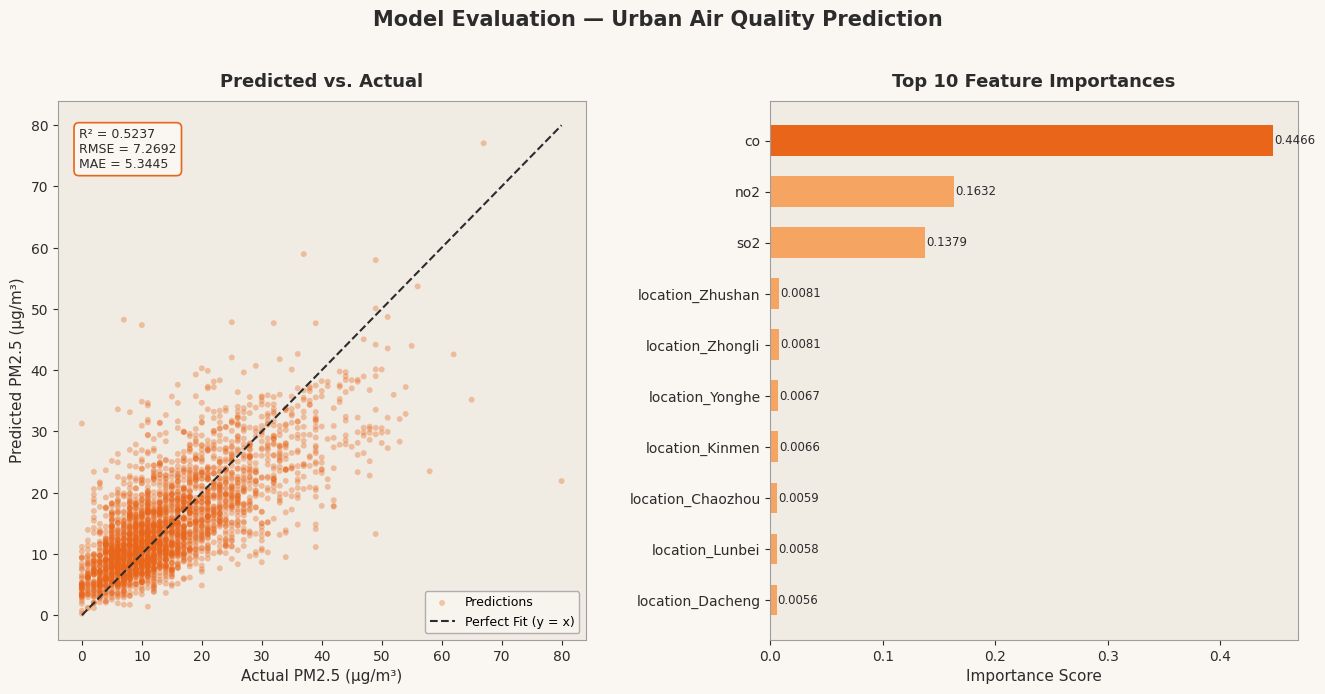

✅ Charts saved as phase7_evaluation.png


In [8]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error

# ============================================================
# EVALUATION & VISUALIZATION
# Daryl (Evaluation & Visualization)
# Input: y_test, y_pred_tuned, tuned_model, X_test (from Erick's Phase 6)
# ============================================================

# --- PALETTE (Modern Premium) ---
BG        = "#FAF7F2"   # light beige
DARK_BG   = "#F0EBE3"   # slightly darker beige for contrast panels
ORANGE    = "#E8651A"   # dark orange accent
ORANGE2   = "#F5A461"   # lighter orange for gradients
DARK      = "#2C2C2C"   # near-black text
GREY      = "#9E9E9E"   # muted grey

# ============================================================
# STEP 1: FINAL EVALUATION METRICS
# ============================================================
r2   = r2_score(y_test, y_pred_tuned)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_tuned))
mae  = mean_absolute_error(y_test, y_pred_tuned)

print("=" * 50)
print("  FINAL MODEL EVALUATION REPORT")
print("=" * 50)
print(f"  R-squared (R²)  :  {r2:.4f}")
print(f"  RMSE            :  {rmse:.4f}  µg/m³")
print(f"  MAE             :  {mae:.4f}  µg/m³")
print("=" * 50)
print(f"  Test Set Size   :  {len(y_test):,} rows")
print(f"  Training Size   :  {len(y_train):,} rows")
print("=" * 50)

# ============================================================
# STEP 2: VISUALIZATIONS
# ============================================================
fig = plt.figure(figsize=(16, 7), facecolor=BG)
fig.suptitle(
    "Model Evaluation — Urban Air Quality Prediction",
    fontsize=15, fontweight="bold", color=DARK, y=1.01
)
gs = gridspec.GridSpec(1, 2, figure=fig, wspace=0.35)

# ------------------------------------------
# CHART 1: Predicted vs. Actual Scatter Plot
# ------------------------------------------
ax1 = fig.add_subplot(gs[0])
ax1.set_facecolor(DARK_BG)

# Sample 3,000 points so the chart doesn't get overcrowded
sample_idx = np.random.choice(len(y_test), size=min(3000, len(y_test)), replace=False)
y_actual_sample  = np.array(y_test)[sample_idx]
y_pred_sample    = np.array(y_pred_tuned)[sample_idx]

ax1.scatter(
    y_actual_sample, y_pred_sample,
    alpha=0.35, color=ORANGE, edgecolors="none", s=18, label="Predictions"
)

# Perfect prediction line
lims = [
    min(y_actual_sample.min(), y_pred_sample.min()),
    max(y_actual_sample.max(), y_pred_sample.max())
]
ax1.plot(lims, lims, color=DARK, linewidth=1.5, linestyle="--", label="Perfect Fit (y = x)")

ax1.set_xlabel("Actual PM2.5 (µg/m³)", fontsize=11, color=DARK)
ax1.set_ylabel("Predicted PM2.5 (µg/m³)", fontsize=11, color=DARK)
ax1.set_title("Predicted vs. Actual", fontsize=13, fontweight="bold", color=DARK, pad=10)
ax1.tick_params(colors=DARK)
ax1.spines[:].set_color(GREY)
ax1.legend(fontsize=9, facecolor=BG, edgecolor=GREY)

# Metrics annotation box
textstr = f"R² = {r2:.4f}\nRMSE = {rmse:.4f}\nMAE = {mae:.4f}"
ax1.text(
    0.04, 0.95, textstr, transform=ax1.transAxes,
    fontsize=9, verticalalignment="top",
    bbox=dict(boxstyle="round,pad=0.4", facecolor=BG, edgecolor=ORANGE, linewidth=1.2),
    color=DARK
)

# ------------------------------------------
# CHART 2: Feature Importance Bar Chart
# ------------------------------------------
ax2 = fig.add_subplot(gs[1])
ax2.set_facecolor(DARK_BG)

importances = tuned_model.feature_importances_
feature_names = X_test.columns.tolist()

# Take top 10 features for readability
top_n = 10
indices = np.argsort(importances)[::-1][:top_n]
top_names  = [feature_names[i] for i in indices]
top_values = importances[indices]

# Color: highlight the top bar in dark orange, rest in lighter orange
colors = [ORANGE if i == 0 else ORANGE2 for i in range(len(top_names))]

bars = ax2.barh(top_names[::-1], top_values[::-1], color=colors[::-1], edgecolor="none", height=0.6)

ax2.set_xlabel("Importance Score", fontsize=11, color=DARK)
ax2.set_title("Top 10 Feature Importances", fontsize=13, fontweight="bold", color=DARK, pad=10)
ax2.tick_params(colors=DARK)
ax2.spines[:].set_color(GREY)

# Value labels on bars
for bar, val in zip(bars, top_values[::-1]):
    ax2.text(
        bar.get_width() + 0.001, bar.get_y() + bar.get_height() / 2,
        f"{val:.4f}", va="center", ha="left", fontsize=8.5, color=DARK
    )

plt.tight_layout()
plt.savefig("phase7_evaluation.png", dpi=150, bbox_inches="tight", facecolor=BG)
plt.show()
print("✅ Charts saved as phase7_evaluation.png")